**Shaima Alruhaili** -
**250001381** -
Final project for DS540  -
**14248**

Natural Language Processing and Sentiment Classification of Online Shopping Reviews


> Add blockquote



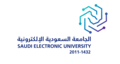

I have divided the code into sections for clarity and ease of understanding. Each section focuses on a specific task, starting with importing the necessary libraries. This helps to keep the code organized and easy to follow.

---




# Upload/ Read and Inspect the Database

In [ ]:
# -------------- Upload and Read the Database --------------------
import pandas as pd  # For data manipulation and analysis
from google.colab import files  # To handle file uploads and downloads in Google Colab


# Read CSV file and Display basics information
uploaded = files.upload()
df = pd.read_csv(list(uploaded.keys())[0])

# ---------- Display Database Properties ----------
print("Database shape is:", df.shape)
print("\nNumber of Records (Rows):", df.shape[0])
print("\nNumber of Features (Columns):", df.shape[1])
print("\nFeature Names and Data Types:\n", df.columns.tolist(), "\n \n", df.dtypes)
print("\nFirst 5 Rows of the Dataset:\n", df.head())

# -------- Summary for all data types --------
print("\nStatistical Summary of All Features:\n")
print(df.describe(include="all"))

# ----------- Inspect the Database ------------
print("\nChecking for Missing Values:")
print(df.isnull().sum())

print("\nChecking for Duplicate Records, number of Duplicates:", df.duplicated().sum())

Saving product_reviews_1000.csv to product_reviews_1000 (1).csv
Database shape is: (1000, 5)

Number of Records (Rows): 1000

Number of Features (Columns): 5

Feature Names and Data Types:
 ['Review Text', 'Label', 'Platform', 'User Name', 'User ID'] 
 
 Review Text    object
Label          object
Platform       object
User Name      object
User ID        object
dtype: object

First 5 Rows of the Dataset:
                                          Review Text     Label  Platform  \
0          Terrible experience, item arrived broken.  Negative    Amazon   
1                     Not bad, but not great either.   Neutral  Flipkart   
2  Absolutely love this! Stylish, durable, and gr...  Positive  Flipkart   
3   Stopped working within a week, very frustrating.  Negative  Flipkart   
4   Stopped working within a week, very frustrating.  Negative    Amazon   

      User Name User ID  
0  Simran Gupta   U0001  
1   Neha Kapoor   U0002  
2   Rohan Gupta   U0003  
3  Simran Verma   U0004  
4  

# Database Cleaning

In [ ]:
# ---------- Database Cleaning ----------
# Make a copy of the original DataFrame to avoid modifying the original data
cleaned_data = df.copy()

# Define the column names for review text and label
TEXT_COL = "Review Text"  # The column name for the review text
LABEL_COL = "Label"       # The column name for the label

# Handle missing values (fill numeric with median, categorical with "Unknown")
for col in cleaned_data.columns:
    if cleaned_data[col].dtype == "object":  # Categorical column
        cleaned_data[col] = cleaned_data[col].fillna("Unknown")  # Fill missing categorical values with "Unknown"
    else:  # Numeric column
        cleaned_data[col] = cleaned_data[col].fillna(cleaned_data[col].median())  # Fill missing numeric values with median

# Drop rows with missing values in the important columns (Review Text, Label)
cleaned_data = cleaned_data.dropna(subset=[TEXT_COL, LABEL_COL])

# Print summary of the cleaning process
print("\nData Cleaning Completed!")
print("\nNumber of Records after Cleaning:", cleaned_data.shape[0])
print("\nRemaining Missing Values (should be 0):", cleaned_data.isnull().sum())

# ---------- Save the Cleaned Database ---------
cleaned_data.to_csv("cleaned_data.csv", index=False)
print("\nCleaned dataset has been saved successfully as 'cleaned_data.csv'")

# Allow file download
files.download("cleaned_data.csv")



Data Cleaning Completed!

Number of Records after Cleaning: 1000

Remaining Missing Values (should be 0): Review Text    0
Label          0
Platform       0
User Name      0
User ID        0
dtype: int64

Cleaned dataset has been saved successfully as 'cleaned_data.csv'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Preprocessing & Feature Extraction

In [ ]:
# ---------- Preprocessing & Feature Extraction ----------
!pip install pyspellchecker
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
import re  # Regular expressions for text cleaning (removing special characters)
import numpy as np  # Numerical operations, used for calculating mean, etc.
from nltk.corpus import stopwords  # NLTK's stopword list for removing common words in English
from nltk.tokenize import word_tokenize  # Used to tokenize (split) the text into words
from nltk.stem import PorterStemmer  # Porter Stemming algorithm to reduce words to their base form
from nltk.stem import WordNetLemmatizer # Importing Lemmatizer to convert words to their base form using context
from textblob import TextBlob  # Used for sentiment analysis (polarity and subjectivity)
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer  # Tools for creating Bag of Words (BOW) and TF-IDF representations
from spellchecker import SpellChecker  # Used to correct spelling errors in the text


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 65.9 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
# Read CSV file
uploaded = files.upload()
df = pd.read_csv(list(uploaded.keys())[0])

TEXT_COL   = "Review Text"                 # Original column containing the raw text
CLEAN_TEXT_COL = "Cleaned_Text"            # Column for processed text

# Safety checks: Ensure that the required columns are available
for col in [TEXT_COL]:
    if col not in df.columns:
        raise ValueError(f"Column '{TEXT_COL}' not found. Available: {list(df.columns)}")

# ---------- Preprocessing function ----------

import nltk
nltk.download('wordnet') # Download the 'wordnet' corpus

# Initialize text preprocessing tools
stop_words = set(stopwords.words('english'))  # Set of common English stop words
stemmer = PorterStemmer()  # Porter Stemmer for word stemming
lemmatizer = WordNetLemmatizer()  # WordNet Lemmatizer for lemmatization
special_char_pattern = re.compile(r'[^a-zA-Z0-9\s]')  # To remove non-alphanumeric characters
spell = SpellChecker()  # Spell checker for correcting spelling errors

# Pre-processing the text data
def preprocess_text(text):
    # Convert to string and convert to lowercase
    text = text.lower()

    # Remove URLs/mentions/hashtags (optional but useful)
    text = re.sub(r"http\S+|www\.\S+|@\w+|#\w+", " ", text)

    # Keep only letters and spaces
    text = re.sub(r"[^a-z\s]", " ", text)

    # Correct spelling (using pyspellchecker)
    text = " ".join([spell.correction(word) for word in text.split()])

    # Tokenize the text
    tokens = word_tokenize(text)

    # Remove stop words and short words (length <= 2)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]

    # Apply lemmatization after stemming
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    # Apply stemming
    tokens = [stemmer.stem(t) for t in tokens]

    # Rejoin the tokens back into a string
    return " ".join(tokens)

# ---------- Apply Preprocessing ----------
df[CLEAN_TEXT_COL] = df[TEXT_COL].apply(preprocess_text)

# ---------- Save the Preprocessed Database ---------
df.to_csv("Preprocessed_data.csv", index=False)
print("\nPreprocessed dataset has been saved successfully as 'Preprocessed_data.csv'")

# Allow file download
files.download("Preprocessed_data.csv")

Saving cleaned_data (1).csv to cleaned_data (1) (1).csv


[nltk_data] Downloading package wordnet to /root/nltk_data...



Preprocessed dataset has been saved successfully as 'Preprocessed_data.csv'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ---------- Feature Extraction ----------
# Read CSV file
uploaded = files.upload()
df = pd.read_csv(list(uploaded.keys())[0])

TEXT_COL   = "Review Text"                 # Original column containing the raw text
CLEAN_TEXT_COL = "Cleaned_Text"            # Column for processed text

# (1) Word count per review
df["word_count"] = df[CLEAN_TEXT_COL].apply(lambda txt: len(txt.split()))

# (2) Average word length per review
df["avg_word_len"] = df[CLEAN_TEXT_COL].apply(lambda txt: np.mean([len(word) for word in txt.split()]))

# (3) Special character count (from raw/original text)
df["special_char_count"] = df[CLEAN_TEXT_COL].apply(lambda txt: len(re.findall(r"[^\w\s]", txt)))

# (4) Review sentiments via TextBlob
df["sent_polarity"] = df[CLEAN_TEXT_COL].apply(lambda txt: TextBlob(txt).sentiment.polarity)
df["sent_subjectivity"] = df[CLEAN_TEXT_COL].apply(lambda txt: TextBlob(txt).sentiment.subjectivity)

# (5) N-grams (CountVectorizer)
sh_tfidf = TfidfVectorizer(ngram_range=(1, 2)).fit_transform(df[CLEAN_TEXT_COL].tolist())

# (6) TF-IDF
sh_tfidf = TfidfVectorizer(ngram_range=(1, 2)).fit_transform(df[CLEAN_TEXT_COL].tolist())

# ---------- Quick preview ----------
print("\nPreview:")
cols_preview = [c for c in ["word_count","avg_word_len","special_char_count",
                            "sent_polarity","sent_subjectivity"] if c in df.columns]
print(df[[TEXT_COL, CLEAN_TEXT_COL] + cols_preview].head())

# Save Features Extracted data in CSV file
df.to_csv("Features_Extracted.csv", index=False)
print("\nFeatures extracted dataset has been saved successfully as 'Features_Extracted.csv'")

# Allow file download
files.download("Features_Extracted.csv")

Saving Preprocessed_data.csv to Preprocessed_data (1).csv

Preview:
                                         Review Text  \
0          Terrible experience, item arrived broken.   
1                     Not bad, but not great either.   
2  Absolutely love this! Stylish, durable, and gr...   
3   Stopped working within a week, very frustrating.   
4   Stopped working within a week, very frustrating.   

                                   Cleaned_Text  word_count  avg_word_len  \
0              terribl experi item arriv broken           5      5.600000   
1                              bad great either           3      4.666667   
2  absolut love stylish durabl great valu money           7      5.428571   
3                stop work within week frustrat           5      5.200000   
4                stop work within week frustrat           5      5.200000   

   special_char_count  sent_polarity  sent_subjectivity  
0                   0          -0.40           0.400000  
1               

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Create TF-IDF Vectorizer and extract top n-grams (unigrams + bigrams)
vectorizer = TfidfVectorizer(ngram_range=(1, 2))
X_tfidf = vectorizer.fit_transform(df['Cleaned_Text'])

# Get top n-grams based on average TF-IDF weight
top_n = 20
top_ngrams = np.array(vectorizer.get_feature_names_out())[np.argsort(np.mean(X_tfidf.toarray(), axis=0))[-top_n:]]

# Print the top n-grams
print("Top 20 n-grams:")
print(top_ngrams)

Top 20 n-grams:
['comfort use' 'comfort' 'use' 'arriv' 'broken' 'item arriv'
 'terribl experi' 'experi' 'arriv broken' 'terribl' 'experi item'
 'deliveri' 'expect' 'stop work' 'stop' 'item' 'work' 'product' 'qualiti'
 'great']


# Visual Representation

In [ ]:
import matplotlib.pyplot as plt  # For creating visualizations and plots.
import seaborn as sns  # A library built on top of matplotlib for creating more attractive and informative statistical graphics.
!pip install wordcloud
from wordcloud import WordCloud  # A library to generate word clouds, visually displaying the most frequent words in the text.


Saving Features_Extracted.csv to Features_Extracted (1).csv


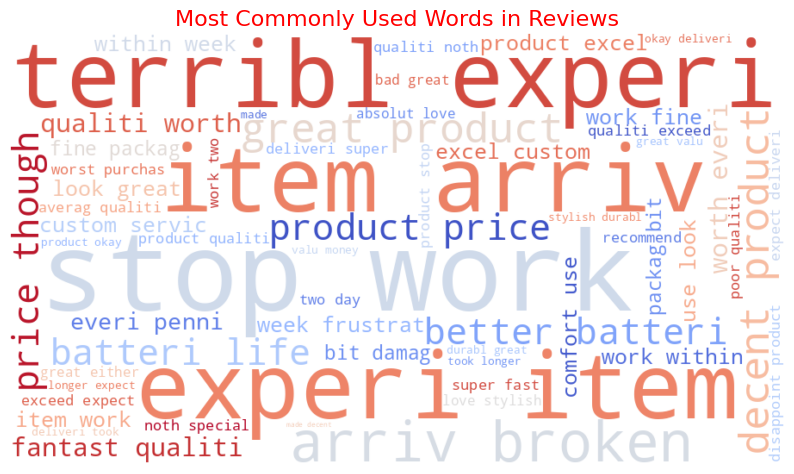

/tmp/ipython-input-3420603512.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Sentiment_Label", palette="magma", order=["Positive", "Neutral", "Negative"])


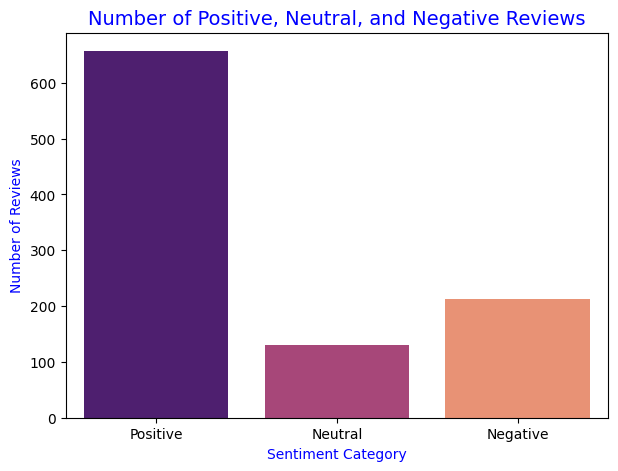

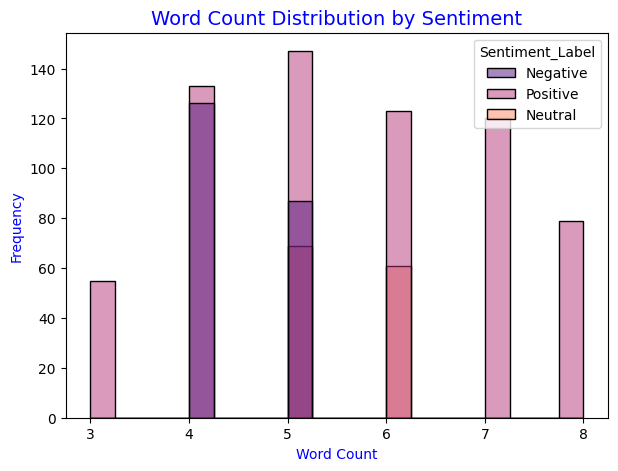

In [ ]:
# Read CSV file
uploaded = files.upload()
df = pd.read_csv(list(uploaded.keys())[0])

# Step 1: Label sentiment based on sent_polarity (already calculated earlier)
def label_sentiment(score):
    # Categorize sentiment based on the polarity score
    if score > 0.05:
        return "Positive"
    elif score < -0.05:
        return "Negative"
    else:
        return "Neutral"

# Step 2: Ensure 'Sentiment_Label' is created using 'sent_polarity'
df["Sentiment_Label"] = df["sent_polarity"].apply(label_sentiment)

# Step 3: Generate Word Cloud for the most common words in reviews
all_words = " ".join(df["Cleaned_Text"].dropna())  # Join all cleaned text into a single string
wordcloud = WordCloud(width=900, height=500, background_color="white", colormap="coolwarm").generate(all_words)

# Plot the Word Cloud with specified colormap
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")  # Hide axes
plt.title("Most Commonly Used Words in Reviews", fontsize=16, color="red")  # Red color for title
plt.show()

# Step 4: Create a bar plot to show the number of reviews by sentiment
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Sentiment_Label", palette="magma", order=["Positive", "Neutral", "Negative"])
plt.title("Number of Positive, Neutral, and Negative Reviews", fontsize=14, color="blue")  # Blue color for title
plt.xlabel("Sentiment Category", color="blue")  # Blue color for x-axis label
plt.ylabel("Number of Reviews", color="blue")  # Blue color for y-axis label
plt.show()

# Step 5: Create a histogram to show the distribution of word counts by sentiment
plt.figure(figsize=(7, 5))
sns.histplot(data=df, x="word_count", hue="Sentiment_Label", palette="magma", bins=20)
plt.title("Word Count Distribution by Sentiment", fontsize=14, color="blue")
plt.xlabel("Word Count", color="blue")
plt.ylabel("Frequency", color="blue")
plt.show()



# Sentiment Analysis Using ML Techniques

In [ ]:
from sklearn.model_selection import train_test_split  # To split the data into training and test sets
from sklearn.ensemble import RandomForestClassifier  # Random Forest model for classification
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score  # Metrics for evaluating the model
from sklearn.preprocessing import LabelEncoder  # For encoding categorical labels
from sklearn.linear_model import LogisticRegression  # Logistic Regression model for classification


Logistic Regression Accuracy: 0.6133333333333333
Random Forest Accuracy: 1.0
Logistic Regression Classification Report:
              precision    recall  f1-score   support

    Negative       0.53      0.28      0.37        71
     Neutral       0.00      0.00      0.00        47
    Positive       0.63      0.90      0.74       182

    accuracy                           0.61       300
   macro avg       0.38      0.39      0.37       300
weighted avg       0.50      0.61      0.54       300

Confusion Matrix for Logistic Regression:
[[ 20   0  51]
 [  0   0  47]
 [ 18   0 164]]

Random Forest Classification Report:
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        71
     Neutral       1.00      1.00      1.00        47
    Positive       1.00      1.00      1.00       182

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


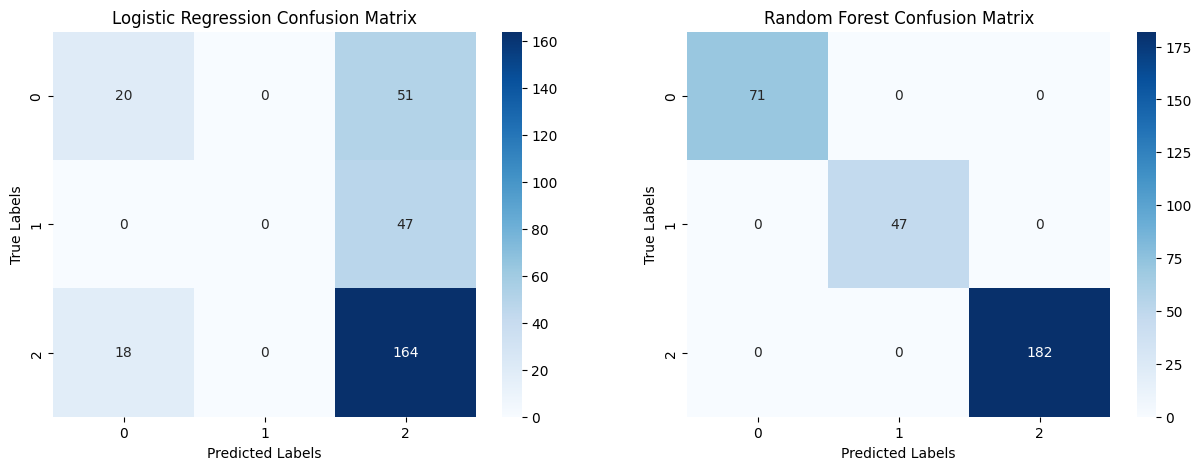

In [ ]:
# Prepare the feature matrix (X) and target variable (y)
X = df[['word_count', 'avg_word_len']]  # Use the pre-existing features
y = df['Sentiment_Label']  # Target variable (Sentiment_Label)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize machine learning models
# Using Logistic Regression
log_reg_model = LogisticRegression(max_iter=1000)

# Using Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train and Evaluate Models
# Train the Logistic Regression model
log_reg_model.fit(X_train, y_train)
log_reg_predictions = log_reg_model.predict(X_test)

# Train the Random Forest model
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

# ---------- Calculate Accuracy ----------
log_reg_accuracy = accuracy_score(y_test, log_reg_predictions)
rf_accuracy = accuracy_score(y_test, rf_predictions)

# Print Accuracy Results
print(f"Logistic Regression Accuracy: {log_reg_accuracy}")
print(f"Random Forest Accuracy: {rf_accuracy}")

# ---------- Evaluate the models ----------
print("Logistic Regression Classification Report:")
print(classification_report(y_test, log_reg_predictions))
print("Confusion Matrix for Logistic Regression:")
print(confusion_matrix(y_test, log_reg_predictions))

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, rf_predictions))
print("Confusion Matrix for Random Forest:")
print(confusion_matrix(y_test, rf_predictions))

# Visualize confusion matrices
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

sns.heatmap(confusion_matrix(y_test, log_reg_predictions), annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title("Logistic Regression Confusion Matrix")
ax[0].set_xlabel("Predicted Labels")
ax[0].set_ylabel("True Labels")

sns.heatmap(confusion_matrix(y_test, rf_predictions), annot=True, fmt='d', cmap='Blues', ax=ax[1])
ax[1].set_title("Random Forest Confusion Matrix")
ax[1].set_xlabel("Predicted Labels")
ax[1].set_ylabel("True Labels")

plt.show()

# Extra Features

In [ ]:
# Extracts the top n-grams based on their average TF-IDF score for a specific sentiment (Positive, Neutral, Negative).
def top_ngrams_by_sentiment(df, text_col, label_col, sentiment, n=10, ngram_range=(1, 2)):

    # Filter reviews for the given sentiment
    subset = df[df[label_col] == sentiment]

    # Return an empty list if no reviews exist for the given sentiment
    if subset.empty:
        return []

    # Create the TF-IDF model for the reviews of the given sentiment
    vectorizer = TfidfVectorizer(ngram_range=ngram_range)
    X = vectorizer.fit_transform(subset[text_col])

    # Compute the average TF-IDF score for each n-gram and sort them
    scores = X.mean(axis=0).A1
    top_idx = scores.argsort()[::-1][:n]
    top_ngrams = vectorizer.get_feature_names_out()[top_idx]

    # Return a list of tuples (ngram, score)
    return list(zip(top_ngrams, scores[top_idx]))

In [ ]:
CLEAN_TEXT_COL = "Cleaned_Text"  # Column name for the cleaned text data
LABEL_COL = "Sentiment_Label"    # Column name for the sentiment labels

# Get the top 10 n-grams for each sentiment
top_pos = top_ngrams_by_sentiment(df, CLEAN_TEXT_COL, LABEL_COL, "Positive", n=10)  # For Positive sentiment
top_neu = top_ngrams_by_sentiment(df, CLEAN_TEXT_COL, LABEL_COL, "Neutral", n=10)   # For Neutral sentiment
top_neg = top_ngrams_by_sentiment(df, CLEAN_TEXT_COL, LABEL_COL, "Negative", n=10)  # For Negative sentiment

# Print the top Positive n-grams with their TF-IDF scores
print("Top Positive N-grams:")
for ng, sc in top_pos:  # Loop through each n-gram and its score in the Positive sentiment
    print(f"- {ng}  (score={sc:.4f})")  # Display n-gram and its score

# Print the top Neutral n-grams with their TF-IDF scores
print("\nTop Neutral N-grams:")
for ng, sc in top_neu:  # Loop through each n-gram and its score in the Neutral sentiment
    print(f"- {ng}  (score={sc:.4f})")  # Display n-gram and its score

# Print the top Negative n-grams with their TF-IDF scores
print("\nTop Negative N-grams:")
for ng, sc in top_neg:  # Loop through each n-gram and its score in the Negative sentiment
    print(f"- {ng}  (score={sc:.4f})")  # Display n-gram and its score


Top Positive N-grams:
- great  (score=0.0859)
- product  (score=0.0742)
- qualiti  (score=0.0712)
- expect  (score=0.0454)
- deliveri  (score=0.0454)
- look great  (score=0.0422)
- use  (score=0.0422)
- comfort  (score=0.0422)
- comfort use  (score=0.0422)
- use look  (score=0.0422)

Top Neutral N-grams:
- work  (score=0.2117)
- stop  (score=0.2117)
- stop work  (score=0.2117)
- work within  (score=0.1987)
- within week  (score=0.1987)
- week  (score=0.1987)
- frustrat  (score=0.1987)
- within  (score=0.1987)
- week frustrat  (score=0.1987)
- two  (score=0.1566)

Top Negative N-grams:
- terribl experi  (score=0.1362)
- terribl  (score=0.1362)
- broken  (score=0.1362)
- arriv  (score=0.1362)
- arriv broken  (score=0.1362)
- experi  (score=0.1362)
- item arriv  (score=0.1362)
- experi item  (score=0.1362)
- item  (score=0.1362)
- purchas ever  (score=0.1136)
